##**[3주차]실습**
- 아래의 실습1), 실습2), 실습3), 실습4), 실습5)의 코드를 완성하시오.


In [ ]:
print("2343035, 신동엽")

In [ ]:
from google.colab import auth

auth.authenticate_user()
!gcloud config get-value account

### 실습1) 활성화 함수 구현
[실습목표]

- 다양한 활성화 함수를 직접 구현해본다.
- 구현한 활성화 함수를 시각화 하여 확인한다.

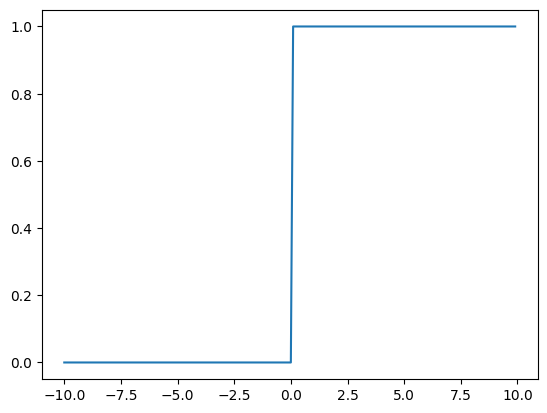

In [8]:
import numpy as np
import matplotlib.pyplot as plt
def step(x):
	###여기에 코드를 작성하시오.###
    return np.where(x >= 0, 1, 0)


x = np.arange(-10.0, 10.0, 0.1)
y = step(x)
plt.plot(x, y)
plt.show()

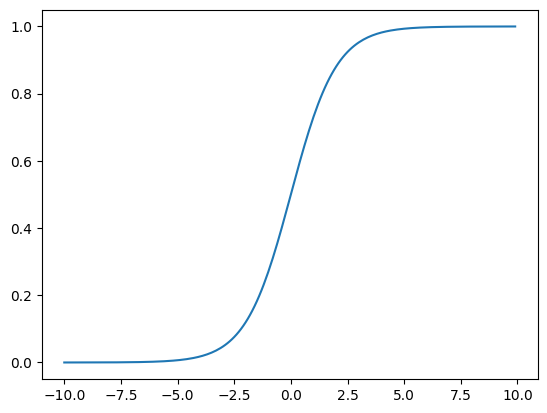

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
	return 1 / (1 + np.exp(-x))

x = np.arange(-10.0, 10.0, 0.1)
y = sigmoid(x)
plt.plot(x, y)
plt.show()

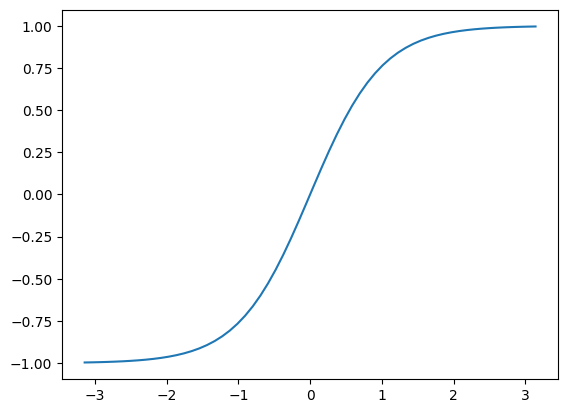

In [12]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-np.pi, np.pi, 60)
y = np.tanh(x)
plt.plot(x, y)
plt.show()

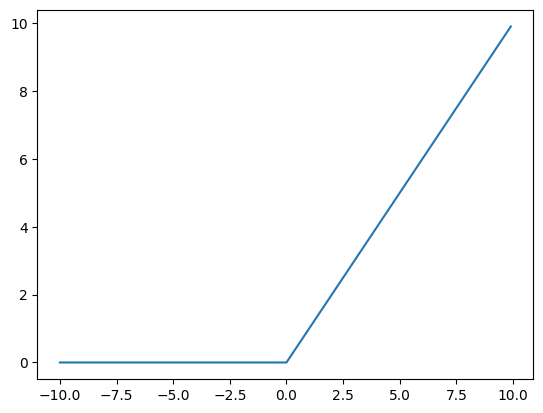

In [13]:
def relu(x):
	###여기에 코드를 작성하시오.###
    return np.maximum(0, x)

x = np.arange(-10.0, 10.0, 0.1)
y = relu(x)
plt.plot(x, y)
plt.show()

### 실습2) MLP 순방향 패스
[실습목표]

- MLP를 numpy 라이브러리를 활용하여 구현하고, 예측을 수행한다.

<출력 형식>
```
[[0 0]] [0] [[0.70938314]]
[[0 1]] [1] [[0.72844306]]
[[1 0]] [1] [[0.71791234]]
[[1 1]] [0] [[0.73598705]]
```



In [ ]:
import numpy as np

# 시그모이드 함수
def actf(x):
	return  1 / (1 + np.exp(-x))

# 훈련 샘플과 정답
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
T = np.array([[0], [1], [1], [0]])

W1 = np.array([[0.10, 0.20],
                 [0.30, 0.40]])
W2 = np.array([[0.50], [0.60]])
B1 = np.array([0.1, 0.2])
B2 = np.array([0.3])

# 순방향 전파 계산
def predict(x):

    ###여기에 코드를 작성하시오.###
    layer0 = x # 입력층
    Z1 = np.dot(layer0, W1) + B1 # 은닉층 행렬 내적 연산
    layer1 = actf(Z1) # 은닉층 활성화 함수 적용
    Z2 = np.dot(layer1, W2) + B2 # 출력층 행렬 내적 연산
    layer2 = actf(Z2) # 출력층 활성화 함수 적용

    return layer0, layer1, layer2

def test():

    ###여기에 코드를 작성하시오.###
    for x,y in zip(X, T):
        x = x.reshape(1, -1) # 입력값을 2차원 배열로 변환
        layer0, layer1, layer2 = predict(x)
        print(x, y, layer2)
test()


###################################################################
# Q1. 여기에 예측 결과가 정확한지 정확하지 않은지 서술하시오.
# : 정확하지 않다

# Q2. 정확하지 않다면, 그 이유를 서술하시오.
# : 순전파만 수행하고 역전파를 수행하지 않았기 때문에 가중치와 편향이 업데이트되지 않아 예측 결과가 정확하지 않다.
###################################################################

[[0 0]] [0] [[0.70938314]]
[[0 1]] [1] [[0.72844306]]
[[1 0]] [1] [[0.71791234]]
[[1 1]] [0] [[0.73598705]]


### 실습3) 경사 하강법 실습
[실습목표]

- 경사하강법을 사용하여 아래 함수의 최소값을 찾는 파이썬 프로그램을 작성하시오.

- $y=(x-3)^2+10$

<출력 형식>
```
손실함수값 ({?}) = {?}
손실함수값 ({?}) = {?}
...
최소값 = {?}
```

In [ ]:
x = 10
learning_rate = 0.2
precision = 0.00001
max_iterations = 100

# 손실함수를 람다식으로 정의한다.
loss_func = lambda x: (x-3)**2+10

# 그래디언트를 람다식으로 정의한다. 손실함수의 1차 미분값이다.
gradient = lambda x: 2*x-6

# 그래디언트 강하법
for i in range(max_iterations):
    ###여기에 코드를 작성하시오.###
    x = x - learning_rate * gradient(x) # 그래디언트 강하법 업데이트 공식
    print("손실함수값(", x, ")=", loss_func(x))

print("최소값 = ", x)

손실함수값( 7.199999999999999 )= 27.639999999999993
손실함수값( 5.52 )= 16.350399999999997
손실함수값( 4.512 )= 12.286143999999998
손실함수값( 3.9071999999999996 )= 10.82301184
손실함수값( 3.54432 )= 10.2962842624
손실함수값( 3.3265919999999998 )= 10.106662334464
손실함수값( 3.1959551999999998 )= 10.03839844040704
손실함수값( 3.11757312 )= 10.013823438546535
손실함수값( 3.070543872 )= 10.004976437876753
손실함수값( 3.0423263232 )= 10.001791517635631
손실함수값( 3.02539579392 )= 10.000644946348826
손실함수값( 3.015237476352 )= 10.000232180685577
손실함수값( 3.0091424858112 )= 10.000083585046807
손실함수값( 3.00548549148672 )= 10.000030090616852
손실함수값( 3.003291294892032 )= 10.000010832622067
손실함수값( 3.0019747769352194 )= 10.000003899743945
손실함수값( 3.0011848661611316 )= 10.00000140390782
손실함수값( 3.000710919696679 )= 10.000000505406815
손실함수값( 3.0004265518180073 )= 10.000000181946453
손실함수값( 3.0002559310908046 )= 10.000000065500723
손실함수값( 3.0001535586544827 )= 10.00000002358026
손실함수값( 3.0000921351926895 )= 10.000000008488893
손실함수값( 3.0000552811156136 )= 10.000000

### 실습4) 2차원 그래디언트 시각화
[실습목표]

#### 실습 4-1) 손실함수가 아래의 함수와 같다고 가정할 때, 손실함수의 그래프를 시각화 해본다.
- $f(x,y)=x^2 + y^2$  


<출력 형식> \
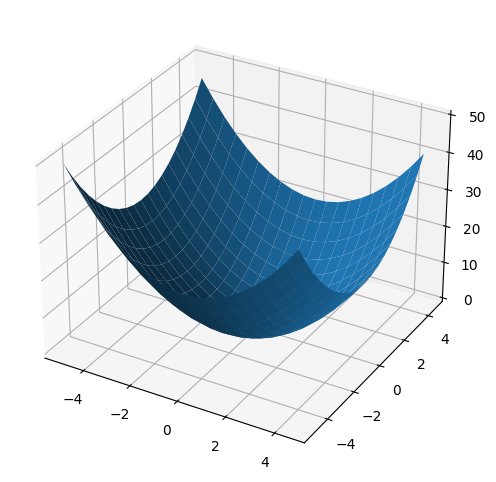


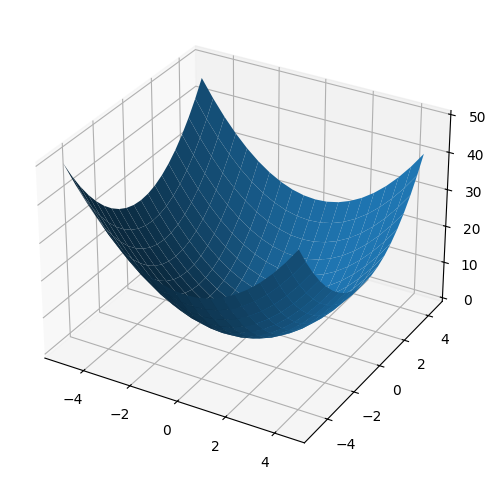

In [ ]:
# 실습 4-1)
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np

###여기에 코드를 작성하시오.###
x = np.arange(-5,5,0.5)
y = np.arange(-5,5,0.5)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# 3차원 그래프를 그린다.
ax.plot_surface(X, Y, Z)
plt.show()

#### 실습 4-2) 손실함수의 그래디언트를 계산하면 아래와 같다.
- 그래디언트에 -1을 곱하여, 그래디언트의 역방향 화살표를 시각화 한다.
- $\nabla{f}=(\partial{f}/\partial{x}, \partial{f}/\partial{y})=(2x,2y)$

<출력 형식>  
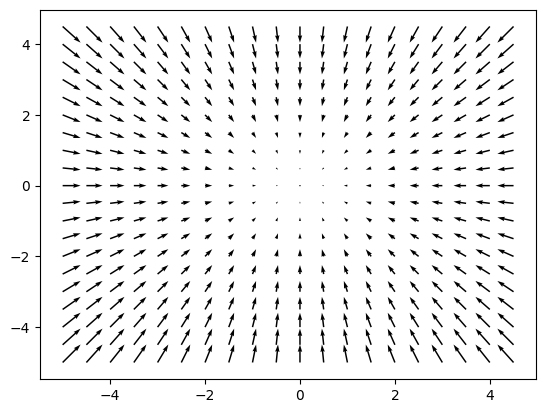

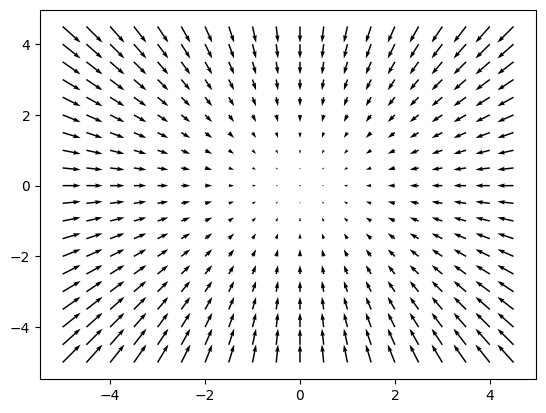

In [2]:
# 실습 4-2)
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(-5,5,0.5)
y = np.arange(-5,5,0.5)
X, Y = np.meshgrid(x, y)
U= -2*X
V= -2*Y

plt.figure()
Q = plt.quiver(X, Y, U, V, units='width')
plt.show()

### 실습5) numpy를 이용한 MLP 구현
[실습목표]

- 앞선 실습2에서는 MLP의 순전파만을 구현하였다. 그 결과 예측값은 정답과는 거리가 멀었다.

- 실습5에서는오차 역전파를 수행하여 실제로 모델을 학습하고, 그 결과를 확인한다.

<출력 형식>
```
[[0 0]] [1] [[0.99196032]]
[[0 1]] [0] [[0.00835708]]
[[1 0]] [0] [[0.00836107]]
[[1 1]] [1] [[0.98974873]]
```

In [3]:
import numpy as np

# 시그모이드 함수
def actf(x):
	return 1/(1+np.exp(-x))

# 시그모이드 함수의 미분치
def actf_deriv(x):
	    return x*(1-x)

# 입력유닛의 개수, 은닉유닛의 개수, 출력유닛의 개수
inputs, hiddens, outputs = 2, 2, 1
learning_rate=0.2

# 훈련 샘플과 정답
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
T = np.array([[1], [0], [0], [1]])

W1 = np.array([[0.10,0.20], [0.30,0.40]])
W2 = np.array([[0.50],[0.60]])
B1 = np.array([0.1, 0.2])
B2 = np.array([0.3])

# 순방향 전파 계산
def predict(x):
        layer0 = x			# 입력을 layer0에 대입한다.
        Z1 = np.dot(layer0, W1)+B1	# 행렬의 곱을 계산한다.
        layer1 = actf(Z1)		# 활성화 함수를 적용한다.
        Z2 = np.dot(layer1, W2)+B2	# 행렬의 곱을 계산한다.
        layer2 = actf(Z2)		# 활성화 함수를 적용한다.
        return layer0, layer1, layer2

# 역방향 전파 계산
def fit():
    global W1, W2, B1, B2		# 우리는 외부에 정의된 변수를 변경해야 한다.
    for i in range(90000):		# 9만번 반복한다.
        for x, y in zip(X, T):		# 학습 샘플을 하나씩 꺼낸다.
            ###여기에 코드를 작성하시오.###
            x = x.reshape(1, -1) # 입력값을 2차원 배열로 변환(1)
            y = y.reshape(1, -1) # 정답값을 2차원 배열로 변환

            layer0, layer1, layer2 = predict(x) # 순방향 전파 계산
            layer2_error = layer2 - y # 출력층의 오차 계산
            layer2_delta = layer2_error * actf_deriv(layer2) # 출력층 델타 계산
            layer1_error = np.dot(layer2_delta, W2.T) # 은닉층의 오차 계산(2)
            layer1_delta = layer1_error * actf_deriv(layer1) # 은닉층 델타 계산(3)

            W2 += -learning_rate * np.dot(layer1.T, layer2_delta) # 출력층 가중치 업데이트
            W1 += -learning_rate * np.dot(layer0.T, layer1_delta) # 은닉층 가중치 업데이트
            B2 += -learning_rate * np.sum(layer2_delta, axis=0) # 출력층 편향 업데이트(5)
            B1 += -learning_rate * np.sum(layer1_delta, axis=0) # 은닉층 편향 업데이트

def test():
    for x, y in zip(X, T):
        ###여기에 코드를 작성하시오.###
        x = x.reshape(1, -1) # 입력값을 2차원 배열로 변환
        layer0, layer1, layer2 = predict(x) # 순방향 전파 계산
        print(x, y, layer2)		# 출력층의 값을 출력해본다.
fit()
test()

[[0 0]] [1] [[0.99196032]]
[[0 1]] [0] [[0.00835708]]
[[1 0]] [0] [[0.00836107]]
[[1 1]] [1] [[0.98974873]]
